In [1]:
# This script reads from MetUM archive (*.pp) files in a specified 
# directory (inputdir) to interpolate a field (relative humidity) 
# to a specified height above sea level (3 km).

# import libraries
import glob
import iris
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# specify the directory containing the MetUM archive files
inputdir='/gws/ssde/j25b/team_x/users/kahern/hackathon/metum/20250629T1200Z'

In [3]:
# use pattern matching to find any MetUM archives
# in the specified input directory. 
allfiles = glob.glob(f"{inputdir}/*.pp")
allfiles.sort()

In [4]:
# Our goal is to interpolate data from model levels
# to a specified height level. 
# We will need height data, which is typically included
# as an auxiliary coordinate in cubes for data with 
# a vertical dimension. Let's try to interpolate relative humidity.

# Load the cube with relative humidity data.
# First, specify a name constraint so we can load
# just the cube(s) with relative humidity.
# Let's also specify that we only want the data from forecast hour 24.
# Then use those constraints to load the data.
fcsthr = 24.
cond = iris.Constraint(name="relative_humidity_with_respect_to_liquid_water", forecast_period=fcsthr)
cubes = iris.load(allfiles, constraints=cond)
rh = cubes[0].data

/home/users/kahern/conda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [5]:
# Pull the altitude data from the cube. 
# The result will be altitude above sea level
# on the model grid. 
zarr = cubes[0].coord("altitude").points

In [6]:
# We could interpolate to multiple levels; for now, 
# let's linearly interpolate the data to 3000 m only.
targz = [3000.0]

In [7]:
# z-indices and weights to do interpolations
ku = np.zeros((len(targz),zarr.shape[1],zarr.shape[2]),dtype=int)
kl = np.zeros((len(targz),zarr.shape[1],zarr.shape[2]),dtype=int)
wu = np.empty((len(targz),zarr.shape[1],zarr.shape[2]))
wl = np.empty((len(targz),zarr.shape[1],zarr.shape[2]))

for k in range(len(targz)):
    tz = targz[k]
    # get the diffs between heights at each level and the target height
    dz = tz - zarr
    
    # maskout all data where dz is negative
    posmask = (dz < 0)
    posdz = np.ma.masked_array(dz, mask=posmask)
    negmask = (dz > 0)        
    negdz = np.ma.masked_array(dz, mask=negmask)
    
    # get an array of the z-indices where non-negative dz is smallest
    posidx = np.nanargmin(posdz, axis=0)
    negidx = np.nanargmax(negdz, axis=0)

    for j in range(posidx.shape[0]):
        for i in range(posidx.shape[1]):
            zu = zarr[negidx[j,i],j,i] # negative dz means zarr is above tz
            zl = zarr[posidx[j,i],j,i] # positive dz means zarr is below tz
            # check: zu (z-upper) should be above (greater than) tz
            #        zl should be below (less than) tz
            if zu >= tz and zl <= tz:
                ku[k,j,i] = negidx[j,i]
                kl[k,j,i] = posidx[j,i]
                interdz = dz[kl[k,j,i],j,i] - dz[ku[k,j,i],j,i]
                wu[k,j,i] = 1.0 - (-dz[ku[k,j,i],j,i] / interdz)
                wl[k,j,i] = 1.0 - ( dz[kl[k,j,i],j,i] / interdz)
            else:
                ku[k,j,i] = -1
                kl[k,j,i] = -1
                wu[k,j,i] = np.nan
                wl[k,j,i] = np.nan

/tmp/ipykernel_145/3986044267.py:32: RuntimeWarning: invalid value encountered in scalar divide
  wu[k,j,i] = 1.0 - (-dz[ku[k,j,i],j,i] / interdz)
/tmp/ipykernel_145/3986044267.py:33: RuntimeWarning: invalid value encountered in scalar divide
  wl[k,j,i] = 1.0 - ( dz[kl[k,j,i],j,i] / interdz)


In [8]:
# Now that we have the weights for interpolation, 
# we can interpolate relative humidity to 3 km.
# Let's make a function that will take in a model field
# and return the field interpolated to 3 km.
def interp2lev(field):
    if field.ndim != 3:
        print(f"error: field passed needs 3 dims ({field.ndim})")
        return field
    if field.shape[0] != zarr.shape[0]:
        print(f"error: field passed has inconsistent z-dim ({field.shape[0]} != {zarr.shape[0]})")
        return field
    if field.shape[1] != zarr.shape[1]:
        print(f"error: field passed has inconsistent y-dim ({field.shape[1]} != {zarr.shape[1]})")
        return field
    if field.shape[2] != zarr.shape[2]:
        print(f"error: field passed has inconsistent x-dim ({field.shape[2]} != {zarr.shape[2]})")
        return field
    
    rarr = np.empty(ku.shape)
    for k in range(rarr.shape[0]):
        for j in range(rarr.shape[1]):
            for i in range(rarr.shape[2]):
                if ku[k,j,i] < 0:
                    rarr[k,j,i] = np.nan
                else:
                    rarr[k,j,i] = (wu[k,j,i] * field[ku[k,j,i],j,i]) \
                        + (wl[k,j,i] * field[kl[k,j,i],j,i])
    
    return rarr

In [9]:
# Call the interpolation function
irh = interp2lev(rh)

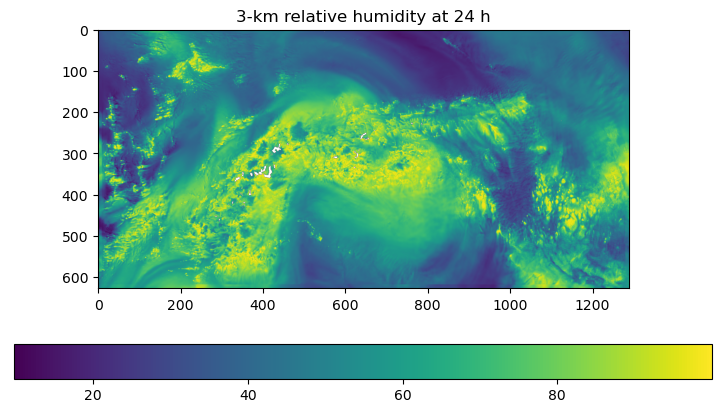

In [12]:
# let's try to plot the 3-km relative humidity
fig = plt.figure(figsize=(9, 4.8))

ax = fig.add_subplot()
ax.set_title(f"3-km relative humidity at {int(fcsthr)} h")
plt.imshow(irh[0,::-1,:]) # <-- uninvert data along y-axis
ax.set_aspect('equal')

cax = fig.add_axes([0.12, 0.1, 0.78, 0.8])
cax.get_xaxis().set_visible(False)
cax.get_yaxis().set_visible(False)
cax.patch.set_alpha(0)
cax.set_frame_on(False)
plt.colorbar(orientation='horizontal')
plt.show()